In [10]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def load_data(batch_size=128):
    # Define the transform for data normalization
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert PIL image to Tensor
        transforms.Normalize((0.5,), (0.5,))  # Normalize the dataset (mean=0.5, std=0.5)
    ])
    
    # Load the dataset (e.g., MNIST) and apply the transform
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    
    # Create DataLoader to iterate through the dataset in batches
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Define the network
class MultilayerNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(MultilayerNet, self).__init__()
        self.layers = nn.ModuleList()
        
        # Input layer
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        
        # Hidden layers
        for i in range(len(hidden_sizes) - 1):
            self.layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
        
        # Output layer
        self.layers.append(nn.Linear(hidden_sizes[-1], num_classes))

    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))
        return x
    
# Define the MLP model for MNIST classification
class MNIST_MLP(nn.Module):
    def __init__(self):
        super(MNIST_MLP, self).__init__()
        # Input layer to hidden layer 1
        self.fc1 = nn.Linear(28*28, 128)  # 128 neurons in first hidden layer
        # Optional second hidden layer
        self.fc2 = nn.Linear(128, 64)  # 64 neurons in second hidden layer
        # Output layer with 10 neurons (for 10 classes)
        self.fc3 = nn.Linear(64, 10)  # 10 neurons for 10 digit classes
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # No activation on output layer, softmax is applied during loss calculation
        return x
    
import torch
import torch.optim as optim
import torch.nn.functional as F

def train_model(net, train_loader, num_epochs=5):
    optimizer = optim.Adam(net.parameters(), lr=0.001)  # Adam optimizer
    criterion = nn.CrossEntropyLoss()  # Loss function for classification
    
    net.train()  # Set the network in training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten the images
            optimizer.zero_grad()  # Zero the parameter gradients
            outputs = net(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

# Function to analyze RQ for each layer
def analyze_rq(net, dataset):
    rq_distributions_by_layer = []
    
    # Get a batch of data
    images, _ = next(iter(dataset))
    images_np = images.view(images.size(0), -1).numpy()  # Flatten the images
    
    # Normalize the input data
    images_np = normalize_data(images_np)
    
    for layer_idx, layer in enumerate(net.layers):
        if isinstance(layer, nn.Linear):
            if layer_idx == 0:
                # For the first layer, use the normalized input data
                input_data = images_np
            else:
                # For subsequent layers, use the output of the previous layer
                input_data = np.dot(input_data, net.layers[layer_idx - 1].weight.detach().cpu().numpy().T)
            
            input_data = normalize_data(input_data)

            # Get the weights for the current layer
            weights = layer.weight.detach().cpu().numpy()
            
            # Compute RQ values for the current layer
            rqs = compute_rq(weights, input_data)
            rq_distributions_by_layer.append(rqs)  # Store the RQ values for this layer
    
    return rq_distributions_by_layer  

# Function to normalize input data
def normalize_data(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_normalized = (X - mean) / (std + 1e-8)  # Avoid division by zero
    return X_normalized


def compute_rq(weights, X):
    # Compute the covariance matrix of the input data X
    C = np.cov(X.T)
    
    # Perform eigendecomposition to get the eigenvalues of the covariance matrix
    eigenvalues = np.linalg.eigvalsh(C)
    lambda_min = np.min(eigenvalues)
    lambda_max = np.max(eigenvalues)

    # Compute Rayleigh Quotient for each weight vector
    rq_values = []
    for w in weights:
        numerator = np.dot(w.T, np.dot(C, w))  # w.T * C * w
        denominator = np.dot(w.T, w)  # w.T * w
        rq = numerator / denominator
        
        # Normalize the RQ using the eigenvalues
        rq_normalized = (rq) / np.sum(eigenvalues)
        rq_values.append(rq_normalized)

    return np.array(rq_values)     

In [ ]:
# Plot RQ distributions for all layers
def plot_rq_distributions(rq_distributions_by_layer):
    num_layers = len(rq_distributions_by_layer)
    
    fig, axes = plt.subplots(num_layers, 1, figsize=(10, num_layers * 3))
    
    for i in range(num_layers):
        sns.kdeplot(rq_distributions_by_layer[i], color='b', fill=True, clip=(0, None), bw_adjust=0.5, ax=axes[i])
        axes[i].set_title(f'Layer {i + 1} RQ Distribution')
        axes[i].set_xlabel('RQ Value')
        axes[i].set_ylabel('Density')
    
    plt.tight_layout()
    plt.show()
    


        
input_size = 28 * 28  # MNIST images are 28x28 pixels
#hidden_sizes = [1024, 512, 256, 128, 64, 32, 16]  # Example hidden layer sizes
hidden_sizes = [100, 100, 100, 100, 100, 100, 100, 100]  # Example hidden layer sizes
hidden_sizes = [50, 50, 50, 50, 50]  # Example hidden layer sizes
num_classes = 10  # 10 output classes (digits 0-9)

# Step 1: Create and train the network
net = MultilayerNet(input_size=input_size, hidden_sizes=hidden_sizes, num_classes=num_classes)
train_loader, test_loader = load_data(batch_size=64)

train_model(net, train_loader, num_epochs=50)

# Step 2: Compute and plot RQ values
input_size = 28 * 28  # MNIST images are 28x28 pixels
#hidden_sizes = [1024, 512, 256, 128, 64, 32, 16]  # Example hidden layer sizes
hidden_sizes = [100, 100, 100, 100, 100, 100, 100, 100]  # Example hidden layer sizes
hidden_sizes = [50, 50, 50, 50, 50]  # Example hidden layer sizes
num_classes = 10  # 10 output classes (digits 0-9)

# Step 1: Create and train the network
net = MultilayerNet(input_size=input_size, hidden_sizes=hidden_sizes, num_classes=num_classes)
train_loader, test_loader = load_data(batch_size=64)

train_model(net, train_loader, num_epochs=50)

# Step 2: Compute and plot RQ values
rq_distributions = analyze_rq(net, train_loader)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Number of layers (based on the length of rq_distributions)
num_layers = len(rq_distributions)
print(num_layers)
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=num_layers, figsize=(14, 2))
mean_rq_per_layer = []

# Loop over each layer and plot the smoothed KDE
for i in range(num_layers):
    #sns.kdeplot(rq_distributions[i], color='b', fill=True, clip=(0, None), bw_adjust=0.5, ax=axes[i])
    sns.kdeplot(rq_distributions[i], color='b', fill=True,  bw_adjust=0.5, ax=axes[i])
    axes[i].set_title(f'Layer {i}')
    axes[i].set_xlabel('Rayleigh Quotient')
    if i==0:
        axes[i].set_ylabel('Density')
    axes[i].set_xlim([0, 0.6])
    mean_rq = np.mean(rq_distributions[i])
    mean_rq_per_layer.append(mean_rq)
  
plt.tight_layout()
plt.show()

# Now plot the mean RQ vs. layer number
plt.figure(figsize=(8, 6))
layer_numbers = np.arange(1, num_layers + 1)
plt.plot(layer_numbers, mean_rq_per_layer, marker='o', linestyle='-', color='r', label='Mean RQ per Layer')
plt.xlabel('Layer Number')
plt.ylabel('Mean Rayleigh Quotient')
plt.title('Mean RQ vs. Layer Number')
plt.grid(True)
plt.legend()
plt.show()

pruning using high and low RQ

In [15]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Function to prune network based on RQ values
def prune_network_by_rq(net, rq_distributions, prune_percentage, prune_type="low"):
    total_nodes = sum([len(rqs) for rqs in rq_distributions])
    num_pruned_nodes = int(prune_percentage * total_nodes)
    
    # Flatten and sort RQ values across all layers
    all_rqs = [(layer_idx, node_idx, rq) for layer_idx, rqs in enumerate(rq_distributions) for node_idx, rq in enumerate(rqs)]
    
    if prune_type == "low":
        sorted_rqs = sorted(all_rqs, key=lambda x: x[2])  # Sort by RQ value (ascending)
    elif prune_type == "high":
        sorted_rqs = sorted(all_rqs, key=lambda x: x[2], reverse=True)  # Sort by RQ value (descending)
    elif prune_type == "random":
        indices = np.random.choice(len(all_rqs), size=num_pruned_nodes, replace=False)  # Random pruning by selecting indices
        sorted_rqs = [all_rqs[i] for i in indices]  # Extract the corresponding elements based on random indices
    
    # Prune the nodes with lowest/highest RQ values
    for layer_idx, node_idx, rq in sorted_rqs[:num_pruned_nodes]:
        # Set the weights and biases of the pruned node to zero
        with torch.no_grad():
            net.layers[layer_idx].weight[:, node_idx] = 0
            if net.layers[layer_idx].bias is not None:
                net.layers[layer_idx].bias[node_idx] = 0
                
    return net

# Function to evaluate the network performance
def evaluate_network(net, test_loader):
    net.eval()  # Set the network in evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(images.size(0), -1)  # Flatten the images
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Function to retrain the pruned network
def retrain_network(net, train_loader, num_epochs=5):
    optimizer = optim.Adam(net.parameters(), lr=0.001)  # Adam optimizer
    criterion = nn.CrossEntropyLoss()  # Loss function for classification
    
    net.train()  # Set the network in training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten the images
            optimizer.zero_grad()  # Zero the parameter gradients
            outputs = net(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")



# Function to prune, evaluate, and plot performance for different pruning strategies
def prune_and_evaluate(net, rq_distributions, train_loader, test_loader, prune_percentages, retrain_epochs=5):
    performance_before_retrain = {'low': [], 'random': [], 'high': []}
    performance_after_retrain = {'low': [], 'random': [], 'high': []}
    
    for prune_percentage in prune_percentages:
        for prune_type in ['low', 'random', 'high']:
            print(f"Pruning {prune_percentage * 100:.2f}% of nodes ({prune_type})...")
            pruned_net = prune_network_by_rq(net, rq_distributions, prune_percentage, prune_type)
            
            # Evaluate performance after pruning
            accuracy_before_retrain = evaluate_network(pruned_net, test_loader)
            performance_before_retrain[prune_type].append(accuracy_before_retrain)
            print(f"Accuracy after pruning ({prune_type}): {accuracy_before_retrain * 100:.2f}%")
            
            # Retrain the pruned network
            retrain_network(pruned_net, train_loader, num_epochs=retrain_epochs)
            
            # Evaluate performance after retraining
            accuracy_after_retrain = evaluate_network(pruned_net, test_loader)
            performance_after_retrain[prune_type].append(accuracy_after_retrain)
            print(f"Accuracy after retraining ({prune_type}): {accuracy_after_retrain * 100:.2f}%")
    
    # Plot the performance before retraining
    plt.figure(figsize=(8, 6))
    for prune_type in ['low', 'high']:
        plt.plot([p * 100 for p in prune_percentages], [p * 100 for p in performance_before_retrain[prune_type]], label=f"Before Retraining ({prune_type})", marker='o')
    plt.xlabel('Pruned Percentage (%)')
    plt.ylabel('Accuracy (%)')
    plt.title('Performance vs Pruned Percentage (Before Retraining)')
    plt.legend()
    plt.show()
    
    # Plot the performance after retraining
    plt.figure(figsize=(8, 6))
    for prune_type in ['low', 'high']:
        plt.plot([p * 100 for p in prune_percentages], [p * 100 for p in performance_after_retrain[prune_type]], label=f"After Retraining ({prune_type})", marker='o')
    plt.xlabel('Pruned Percentage (%)')
    plt.ylabel('Accuracy (%)')
    plt.title('Performance vs Pruned Percentage (After Retraining)')
    plt.legend()
    plt.show()



# Example Usage
train_loader, test_loader = load_data(batch_size=128)

# Step 1: Train the network
input_size = 28 * 28
hidden_sizes = [784, 100, 100, 100, 64]
num_classes = 10
net = MultilayerNet(input_size=input_size, hidden_sizes=hidden_sizes, num_classes=num_classes)
#net = MNIST_MLP()
train_model(net, train_loader, num_epochs=20)

# Step 2: Analyze RQ for each layer
rq_distributions = analyze_rq(net, train_loader)

# Step 3: Prune and evaluate the network
prune_percentages = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]  # Test different levels of pruning
prune_and_evaluate(net, rq_distributions, train_loader, test_loader, prune_percentages, retrain_epochs=20)

Epoch 1, Loss: 1.2624140930836643
Epoch 2, Loss: 1.069360750189214
Epoch 3, Loss: 1.0358674838853035
Epoch 4, Loss: 1.0189226401894331
Epoch 5, Loss: 1.0051279109932467
Epoch 6, Loss: 0.9970944138732292
Epoch 7, Loss: 0.9914460883720089
Epoch 8, Loss: 0.9879002763010037
Epoch 9, Loss: 0.979492788375822
Epoch 10, Loss: 0.9757608454873059
Epoch 11, Loss: 0.9747803718296449
Epoch 12, Loss: 0.9690920423342984
Epoch 13, Loss: 0.887977231349518
Epoch 14, Loss: 0.5482834915616619
Epoch 15, Loss: 0.5303481994534353
Epoch 16, Loss: 0.5247332345702247
Epoch 17, Loss: 0.521448217157616
Epoch 18, Loss: 0.5158692150354893
Epoch 19, Loss: 0.5166433962550498
Epoch 20, Loss: 0.5116475146335325
Pruning 0.00% of nodes (low)...
Accuracy after pruning (low): 77.48%
Epoch 1, Loss: 0.5133357140174044
Epoch 2, Loss: 0.5097115851605116
Epoch 3, Loss: 0.508722155396618
Epoch 4, Loss: 0.5050859911355383
Epoch 5, Loss: 0.5060917692525047
Epoch 6, Loss: 0.5064004441059983
Epoch 7, Loss: 0.5054661011390849
Epoch 8

Epoch 1, Loss: 0.8422955975158891
Epoch 2, Loss: 0.6022288743684541
Epoch 3, Loss: 0.5664802753944387


KeyboardInterrupt: 

RNN and temporal RQ

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# 1. Generate synthetic temporal data with a specific time-scale for memory
def generate_temporal_data(n_samples, sequence_length, n_features, time_scale):
    data = np.random.randn(n_samples, sequence_length, n_features)
    for i in range(1, sequence_length):
        decay_factor = np.exp(-i / time_scale)
        data[:, i, :] = decay_factor * data[:, i - 1, :] + (1 - decay_factor) * np.random.randn(n_samples, n_features)
    return data

# Example parameters for data simulation
n_samples = 1000
sequence_length = 20
n_features = 10
time_scale = 5

X = generate_temporal_data(n_samples, sequence_length, n_features, time_scale)
y = np.random.randint(0, 2, n_samples)

# 2. Define the RNN model
class RNNNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNNNet, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(num_layers, x.size(0), hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)  # RNN forward pass
        out = self.fc(out[:, -1, :])  # Use last time-step output
        return out

# 3. Prepare DataLoader
def prepare_dataloader(X, y, batch_size=32):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader

train_loader = prepare_dataloader(X[:800], y[:800], batch_size=32)
test_loader = prepare_dataloader(X[800:], y[800:], batch_size=32)

# 4. Train the RNN model
def train_model(net, train_loader, num_epochs=5):
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    net.train()
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for sequences, labels in train_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

# 5. Compute Temporal Rayleigh Quotient (RQ) using the hidden state output
def compute_temporal_rq(weights, X_hidden):
    C = np.cov(X_hidden.T)  # Compute covariance matrix over hidden states
    
    rq_values = []
    for w in weights:
        numerator = np.dot(w.T, np.dot(C, w))
        denominator = np.dot(w.T, w)
        rq = numerator / denominator
        rq_values.append(rq)
    return np.array(rq_values)

def analyze_temporal_rq(net, train_loader):
    temporal_rq_values = []
    with torch.no_grad():
        for sequences, _ in train_loader:
            sequences = sequences.to(device)
            hidden_states, _ = net.rnn(sequences)  # Get hidden states from RNN
            hidden_states_np = hidden_states[:, -1, :].cpu().numpy()  # Use the hidden states from the last time step
            weights_rnn = net.rnn.weight_hh_l0.detach().cpu().numpy()
            rq_values = compute_temporal_rq(weights_rnn, hidden_states_np)
            temporal_rq_values.extend(rq_values)
    return temporal_rq_values

# 6. Prune based on RQ values
def prune_rnn_based_on_rq(net, rq_values, percentage, strategy="low"):
    rq_values_flat = np.array(rq_values)
    
    # Sort indices by RQ values (either low or high)
    if strategy == "low":
        sorted_indices = np.argsort(rq_values_flat)
    elif strategy == "high":
        sorted_indices = np.argsort(-rq_values_flat)
    elif strategy == "random":
        sorted_indices = np.random.permutation(len(rq_values_flat))

    # Prune the specified percentage of nodes
    n_to_prune = int(percentage * len(sorted_indices))
    prune_indices = sorted_indices[:n_to_prune]
    
    # Ensure the indices are within the bounds of the weight matrix dimensions
    prune_indices = prune_indices[prune_indices < net.rnn.weight_hh_l0.size(0)]  # Fix here
    
    # Prune the RNN weights by setting low RQ weights to zero
    with torch.no_grad():
        for i in prune_indices:
            net.rnn.weight_hh_l0[i] = 0  # Set pruned weights to 0

    print(f"Pruned {len(prune_indices)} nodes based on {strategy} RQ values.")

# 7. Evaluate model performance
def evaluate_model(net, test_loader):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = net(sequences)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

# 8. Retrain after pruning
def retrain_after_pruning(net, train_loader, num_epochs=5):
    train_model(net, train_loader, num_epochs)

# 9. Perform pruning analysis
def pruning_analysis(net, rq_values, strategies, percentages):
    performance_before = evaluate_model(net, test_loader)
    print(f"Performance before pruning: {performance_before}%")

    performance_after_pruning = {}
    performance_after_retraining = {}

    for strategy in strategies:
        performance_after_pruning[strategy] = []
        performance_after_retraining[strategy] = []

        for percentage in percentages:
            # Create a copy of the network for pruning
            pruned_net = RNNNet(input_size, hidden_size, num_layers, num_classes).to(device)
            pruned_net.load_state_dict(net.state_dict())  # Copy weights
            
            # Step 3: Prune based on RQ
            prune_rnn_based_on_rq(pruned_net, rq_values, percentage, strategy)
            
            # Step 4: Evaluate after pruning
            accuracy_after_pruning = evaluate_model(pruned_net, test_loader)
            performance_after_pruning[strategy].append(accuracy_after_pruning)

            # Step 5: Retrain after pruning
            retrain_after_pruning(pruned_net, train_loader, num_epochs=5)
            accuracy_after_retraining = evaluate_model(pruned_net, test_loader)
            performance_after_retraining[strategy].append(accuracy_after_retraining)

    return performance_before, performance_after_pruning, performance_after_retraining

# 10. Main execution
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = n_features
hidden_size = 50
num_layers = 1
num_classes = 2

# Initialize network
net = RNNNet(input_size, hidden_size, num_layers, num_classes).to(device)

# Step 1: Train the RNN
train_model(net, train_loader, num_epochs=20)

# Step 2: Compute temporal RQ
temporal_rq_values = analyze_temporal_rq(net, train_loader)

# Define pruning strategies and percentages
strategies = ["low", "high", "random"]
percentages = np.linspace(0.01, 0.99, 9)

# Perform pruning analysis
performance_before, performance_after_pruning, performance_after_retraining = pruning_analysis(net, temporal_rq_values, strategies, percentages)

# Plot the performance before and after pruning
def plot_pruning_performance(performance_before, performance_after_pruning, performance_after_retraining):
    plt.figure(figsize=(10, 6))
    
    # Plot before pruning
    plt.subplot(2, 1, 1)
    plt.plot(percentages, [performance_before] * len(percentages), label="Before Pruning", linestyle='--')
    for strategy in performance_after_pruning:
        plt.plot(percentages, performance_after_pruning[strategy], label=f"After Pruning ({strategy})")
    plt.xlabel("Percentage of Nodes Pruned")
    plt.ylabel("Accuracy (%)")
    plt.title("Performance After Pruning")
    plt.legend()

    # Plot after retraining
    plt.subplot(2, 1, 2)
    for strategy in performance_after_retraining:
        plt.plot(percentages, performance_after_retraining[strategy], label=f"After Retraining ({strategy})")
    plt.xlabel("Percentage of Nodes Pruned")
    plt.ylabel("Accuracy (%)")
    plt.title("Performance After Retraining")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_pruning_performance(performance_before, performance_after_pruning, performance_after_retraining)

batch optimization for MNIST

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from scipy.optimize import minimize

# Load MNIST dataset
def load_mnist():
    mnist = fetch_openml('mnist_784', version=1)
    X, y = mnist['data'], mnist['target']
    return X.values.astype(np.float32) / 255.0  # Normalize between 0 and 1

# Function to compute covariance matrix
def compute_covariance_matrix(X_batch):
    return np.cov(X_batch, rowvar=False)

# Optimization-based partitioning to minimize covariance variance
def partition_covariance_minimization(X, num_batches):
    batch_size = len(X) // num_batches

    def objective(partition):
        partitioned_data = [X[partition == i] for i in range(num_batches)]
        cov_matrices = [compute_covariance_matrix(batch) for batch in partitioned_data]
        
        # Use Frobenius norm as a scalar measure of each covariance matrix
        frobenius_norms = [np.linalg.norm(cov_matrix, 'fro') for cov_matrix in cov_matrices]
        
        # Compute variance of the Frobenius norms
        return np.var(frobenius_norms)

    # Initial random partition
    initial_partition = np.random.randint(0, num_batches, size=len(X))

    # Optimize partitioning to minimize covariance variance
    result = minimize(objective, initial_partition, method='Powell', options={'maxiter': 100, 'disp': True, 'ftol': 1e-4})
    optimized_partition = np.round(result.x).astype(int)
    return optimized_partition

# # Function to compute covariance variance
# def compute_covariance_variance(cov_matrices):
#     # Compute the Frobenius norm of each covariance matrix
#     frobenius_norms = [np.linalg.norm(cov_matrix, 'fro') for cov_matrix in cov_matrices]
#     return np.var(frobenius_norms)

from joblib import Parallel, delayed

# Parallelized function to compute Frobenius norms
def compute_frobenius_norm(cov_matrix):
    return np.linalg.norm(cov_matrix, 'fro')

# Function to compute covariance variance using parallelization
def compute_covariance_variance(cov_matrices):
    # Use Parallel from joblib to compute Frobenius norms in parallel
    frobenius_norms = Parallel(n_jobs=-1)(delayed(compute_frobenius_norm)(cov) for cov in cov_matrices)
    
    # Return the variance of the Frobenius norms
    return np.var(frobenius_norms)


# Random sampling of data for batch creation
def random_sampling(X, batch_size, num_batches):
    cov_matrices = []
    for _ in range(num_batches):
        indices = np.random.choice(len(X), batch_size, replace=False)
        X_batch = X[indices]
        cov_matrices.append(compute_covariance_matrix(X_batch))
    return cov_matrices

# Function to analyze covariance variance with and without optimization
def analyze_covariance_variance_mnist(batch_sizes, num_batches=10):
    X = load_mnist()
    cov_variances_no_opt = []
    cov_variances_opt = []

    for batch_size in batch_sizes:
        # Without optimization (random sampling)
        cov_matrices_no_opt = random_sampling(X, batch_size, num_batches)
        variance_no_opt = compute_covariance_variance(cov_matrices_no_opt)
        cov_variances_no_opt.append(variance_no_opt)

        # With optimization (variance minimization)
        optimized_partition = partition_covariance_minimization(X, num_batches)
        cov_matrices_opt = [compute_covariance_matrix(X[optimized_partition == i]) for i in range(num_batches)]
        variance_opt = compute_covariance_variance(cov_matrices_opt)
        cov_variances_opt.append(variance_opt)
        print(batch_size)

    return cov_variances_no_opt, cov_variances_opt

# Function to plot covariance variance as a curve for different batch sizes
def plot_covariance_variance(batch_sizes, variances_no_opt, variances_opt):
    plt.figure(figsize=(10, 6))
    plt.plot(batch_sizes, variances_no_opt, label='Without Optimization', marker='o')
    plt.plot(batch_sizes, variances_opt, label='With Optimization', marker='o')
    plt.xlabel('Batch Size')
    plt.ylabel('Covariance Matrix Variance')
    plt.title('Covariance Matrix Variance vs. Batch Size (With and Without Optimization)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define batch sizes and run the analysis
batch_sizes = [50, 500]
variances_no_opt, variances_opt = analyze_covariance_variance_mnist(batch_sizes)

# Plot the results
plot_covariance_variance(batch_sizes, variances_no_opt, variances_opt)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import copy

def ablation_analysis(net, dataloader, criterion, rq_distributions):
    """
    Perform ablation analysis by removing nodes in the network
    and comparing the loss before and after the ablation.
    """
    layer_importances = []

    # Compute the original loss before ablation
    original_loss = compute_network_loss(net, dataloader, criterion)

    # Loop over each layer
    for layer_idx, layer in enumerate(net.layers):
        layer_importance = []

        # Loop over each node in the layer
        for node_idx in range(layer.out_features):  # Assuming Linear layer
            print(layer_idx, node_idx)
            # Clone the original network to avoid accumulating changes
            net_copy = copy.deepcopy(net)

            # Get the specific layer to ablate in the cloned network
            layer_copy = net_copy.layers[layer_idx]

            # Zero out the node by setting its weights to 0 in the copied network
            ablated_weights = layer_copy.weight.clone()
            ablated_weights[:, node_idx] = 0  # Ablate the node by setting its weights to 0
            layer_copy.weight = nn.Parameter(ablated_weights.to(layer_copy.weight.device))

            # If the layer has bias, update it similarly (if ablation affects bias)
            if layer_copy.bias is not None:
                ablated_bias = layer_copy.bias.clone()
                layer_copy.bias = nn.Parameter(ablated_bias.to(layer_copy.bias.device))

            # Compute loss after ablation on the cloned network
            ablation_loss = compute_network_loss(net_copy, dataloader, criterion)

            # Compute importance as the difference in loss
            importance = ablation_loss - original_loss
            layer_importance.append(importance)

        layer_importances.append(layer_importance)

    return layer_importances



def compute_network_loss(net, dataloader, criterion):
    net.eval()
    total_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)  # Move data to the same device

            images = images.view(images.size(0), -1)  # Flatten the images

            outputs = net(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
    
    return total_loss / total_samples


def plot_rq_vs_importance(rq_distributions, layer_importances):
    """ Plot RQ vs Importance for each layer """
    num_layers = len(rq_distributions)
    
    for layer_idx in range(num_layers):
        plt.figure(figsize=(8, 6))
        plt.scatter(rq_distributions[layer_idx], layer_importances[layer_idx], c='b', alpha=0.6)
        plt.xlabel('Rayleigh Quotient (RQ)')
        plt.ylabel('Importance (Loss Change)')
        plt.title(f'Layer {layer_idx+1}: RQ vs Importance')
        plt.grid(True)
        plt.show()

# Example Usage:
# Assuming you have a fully trained network `net`, a validation dataloader `val_loader`,
# and precomputed `rq_distributions` for each layer.

criterion = torch.nn.CrossEntropyLoss()  # Define your loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Ensure device is set
    
original_loss = compute_network_loss(net, test_loader, criterion)
print(original_loss)

# Perform ablation analysis
layer_importances = ablation_analysis(net, test_loader, criterion, rq_distributions)

# Plot RQ vs Importance for each layer
plot_rq_vs_importance(rq_distributions, layer_importances)

In [ ]:
# Get the first batch from train_loader
batch = next(iter(train_loader))

# Check if batch contains two elements (images and labels)
print(f"Batch contains: {len(batch)} elements")

# Assuming the batch has images and labels
images, labels = batch

# Check the shapes
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

# Example of plotting the first image in the batch
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [ ]:
# Extract one batch of data
data_iter = iter(train_loader)
images, labels = data_iter.next()

# Reshape images to 2D (flatten) and compute covariance matrix
images_flat = images.view(images.size(0), -1).numpy()  # Flatten images
cov_matrix = np.cov(images_flat, rowvar=False)  # Compute covariance matrix

# Plot covariance matrix
plt.figure(figsize=(8, 6))
plt.imshow(cov_matrix, cmap='viridis')
plt.title("Covariance Matrix of Normalized Data")
plt.colorbar()
plt.show()

In [ ]:
# Restructure rq_distributions if needed
# Example: Group RQ values by layer
# Parameters of the network
input_size = 28 * 28  # Input layer (e.g., for images)
hidden_sizes = [128, 64]  # Hidden layers
num_classes = 10  # Output layer

# Define number of nodes per layer
num_nodes_per_layer = [input_size] + hidden_sizes + [num_classes]

# Example printout of the number of nodes per layer
print("Number of nodes per layer:", num_nodes_per_layer)

#num_nodes_per_layer = [128, 64, 32]  # Example sizes of each layer
rq_distributions_by_layer = []
start_idx = 0

for num_nodes in num_nodes_per_layer:
    rq_distributions_by_layer.append(rq_distributions[start_idx:start_idx + num_nodes])
    start_idx += num_nodes


# for i, layer_rq in enumerate(rq_distributions):
#     print(f"Layer {i} has {len(layer_rq)} RQ values.")

In [ ]:
# import numpy as np
# import torch

# # Compute Rayleigh Quotient
# def compute_rq(weights, X):
#     """
#     Computes Rayleigh Quotient for given weights and inputs X.
    
#     Parameters:
#     - weights: The weights of the layer (e.g., shape [output_size, input_size]).
#     - X: Input data to the layer (batch_size, input_size).
    
#     Returns:
#     - RQ: The Rayleigh Quotient for the given weights and inputs.
#     """
#     C = X.T @ X  # Covariance matrix
#     numerator = np.dot(weights.T, np.dot(C, weights))
#     denominator = np.dot(weights.T, weights)
#     return numerator / denominator
# # Analyze RQ distributions for different batch sizes
# def analyze_rq_batch_size(net, train_loader, batch_sizes):
#     rq_distributions = []
#     for batch_size in batch_sizes:
#         rqs = []
#         for images, _ in train_loader:
#             images = images.view(images.size(0), -1)  # Flatten the images (batch_size, 28*28)
#             if images.size(0) > batch_size:
#                 images = images[:batch_size]  # Ensure we're only using the current batch size

#             # Forward pass through the network to get activations
#             with torch.no_grad():
#                 output = net(images)

#             # Get weights of the first layer
#             weights = list(net.parameters())[0].detach().numpy()  # (hidden_size, input_size)
            
#             # Compute RQ for the first layer weights and inputs
#             rqs.append(compute_rq(weights, images.numpy()))  
        
#         rq_distributions.append(np.array(rqs).flatten())  # Store RQ distribution for this batch size
    
#     return rq_distributions

# # Example usage:
# batch_sizes = [16, 32, 64, 128]  # Test different batch sizes
# train_loader, _ = load_datasets(batch_size=batch_sizes[0])  # Assuming you have a function for loading datasets
# net = MultilayerNet(input_size=28*28, hidden_sizes=[128, 64], num_classes=10)  # Define network

# # Analyze the RQ distribution for different batch sizes
# rq_distributions = analyze_rq_batch_size(net, train_loader, batch_sizes)

# # Now plot or further analyze the rq_distributions for each batch size

In [ ]:
import numpy as np
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt



# Compute Mutual Information (MI) between input and predicted labels
def compute_mutual_information(X, Y, n_bins=10):
    X_flat = X.reshape(X.shape[0], -1)

    # Binning using KBinsDiscretizer
    discretizer_X = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    X_binned = discretizer_X.fit_transform(X_flat)

    # Compute MI for each sample in the batch
    mi_values = []
    for i in range(X_binned.shape[0]):
        mi_values.append(mutual_info_score(X_binned[i], Y))  # Compare binned input with predicted labels
    
    return np.mean(mi_values)

# Analyze MI vs RQ values for the trained network
def analyze_mi_vs_rq(net, dataset, device, n_bins=10):
    rq_values = []
    mi_values = []
    
    for images, _ in dataset:
        images = images.to(device).view(images.size(0), -1)  # Flatten images
        with torch.no_grad():
            output = net(images)
            predicted_labels = torch.argmax(output, dim=1).cpu().numpy()  # Get predicted class labels
        
        # Get weights of the first layer (for example)
        weights = list(net.parameters())[0].detach().cpu().numpy()
        
        # Compute RQ for the first layer weights and inputs
        rq_values.append(compute_rq(weights, images.cpu().numpy()))
        
        # Compute MI between inputs and predicted labels
        mi = compute_mutual_information(images.cpu().numpy(), predicted_labels, n_bins=n_bins)
        mi_values.append(mi)
    
    # Flatten and align lengths of RQ and MI values
    rq_values = np.concatenate(rq_values, axis=0)
    mi_values = np.array(mi_values)

    min_length = min(len(rq_values), len(mi_values))
    return rq_values[:min_length], mi_values[:min_length]

# Plot RQ vs MI
def plot_mi_vs_rq(rq_values, mi_values):
    """Plot MI vs RQ"""
    plt.figure(figsize=(8, 6))
    plt.scatter(rq_values, mi_values, c='blue', alpha=0.5)
    plt.xlabel('RQ Score')
    plt.ylabel('Mutual Information')
    plt.title('Mutual Information vs RQ Score')
    plt.grid(True)
    plt.show()

# Perform MI vs RQ analysis on the trained network
device = 'cpu'
rq_values, mi_values = analyze_mi_vs_rq(trained_net, train_loader, device, n_bins=10)
plot_mi_vs_rq(rq_values, mi_values)

In [ ]:
# Loading a different dataset
def load_cifar10(batch_size):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
    
    train_loader = DataLoader.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Training with different cost functions
def train_with_cost_function(net, train_loader, cost_function):
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    
    for epoch in range(5):  # Limited epochs for experimentation
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten input
            optimizer.zero_grad()
            outputs = net(images)
            
            # Compute loss based on the provided cost function
            if cost_function == 'cross_entropy':
                loss = nn.CrossEntropyLoss()(outputs, labels)
            elif cost_function == 'mse':
                labels_one_hot = nn.functional.one_hot(labels, num_classes=10).float()
                loss = nn.MSELoss()(outputs, labels_one_hot)
            
            loss.backward()
            optimizer.step()

# Example usage
train_loader, test_loader = load_cifar10(batch_size=64)
net = MultilayerNet(input_size=32*32*3, hidden_sizes=[256, 128], num_classes=10)
train_with_cost_function(net, train_loader, cost_function='cross_entropy')

In [ ]:
# Loading a different dataset
def load_cifar10(batch_size):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
    
    train_loader = DataLoader.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Training with different cost functions
def train_with_cost_function(net, train_loader, cost_function):
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    
    for epoch in range(5):  # Limited epochs for experimentation
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten input
            optimizer.zero_grad()
            outputs = net(images)
            
            # Compute loss based on the provided cost function
            if cost_function == 'cross_entropy':
                loss = nn.CrossEntropyLoss()(outputs, labels)
            elif cost_function == 'mse':
                labels_one_hot = nn.functional.one_hot(labels, num_classes=10).float()
                loss = nn.MSELoss()(outputs, labels_one_hot)
            
            loss.backward()
            optimizer.step()

# Example usage
train_loader, test_loader = load_cifar10(batch_size=64)
net = MultilayerNet(input_size=32*32*3, hidden_sizes=[256, 128], num_classes=10)
train_with_cost_function(net, train_loader, cost_function='cross_entropy')

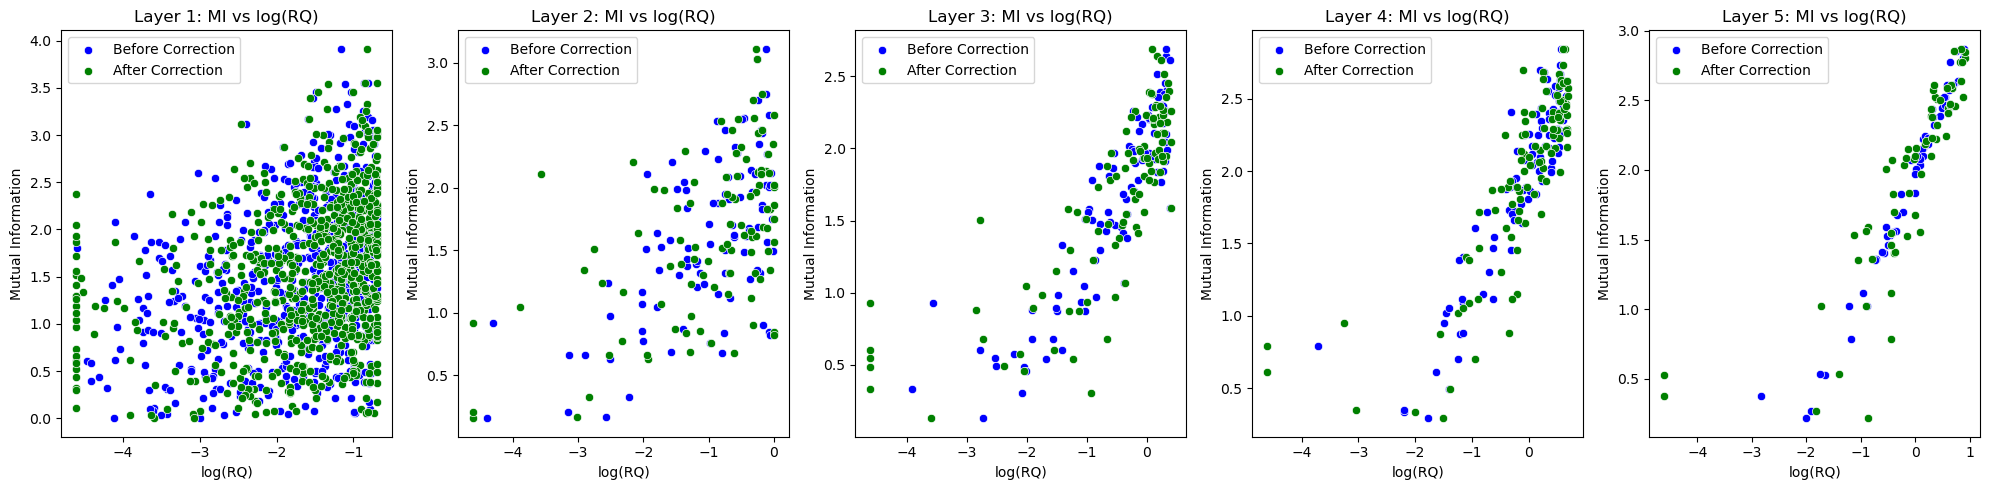

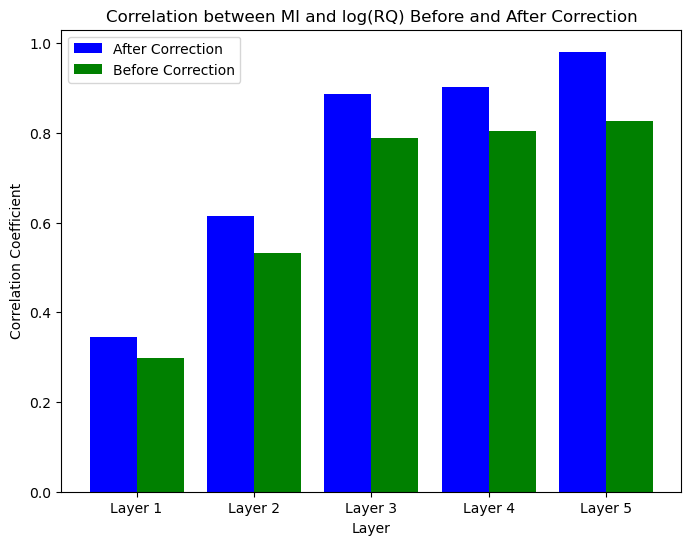

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Function to generate schematic data for MI and RQ with positive correlation
def generate_schematic_data(num_nodes, corr_strength, layer_number):
    # Generate RQ values in the range [0, 0.5 * layer_number]
    rq_values = np.random.uniform(0.01, 0.5 * layer_number, size=num_nodes)
    
    # Generate MI values positively correlated with log(RQ)
    noise = np.random.normal(loc=0, scale=(1 - corr_strength), size=num_nodes)
    mi = np.abs(np.log(rq_values) * corr_strength + noise + 2.0)  # MI increases with log(RQ)
    
    return mi, rq_values

# Function to apply stochastic correction term to RQ values
def apply_correction_term(rq_values, layer_number):
    # Adding a stochastic correction term that slightly improves correlation
    random_noise = np.random.normal(loc=0, scale=0.05 * layer_number, size=len(rq_values))
    correction_term = 0.05 * np.sin(rq_values * layer_number) + random_noise
    
    # Correct the RQ values while ensuring they remain in a valid range [0, 0.5 * layer_number]
    corrected_rq = np.clip(rq_values + correction_term, 0.01, 0.5 * layer_number)
    
    return corrected_rq

# Layer sizes and correlation strengths
layer_sizes = [28*28, 100, 100, 100, 64]
corr_strengths = [0.3, 0.5, 0.7, 0.8, 0.9]  # Weaker correlation in early layers, stronger in later layers

# Generate and plot data for each layer
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

correlations_before = []
correlations_after = []

for i, size in enumerate(layer_sizes):
    layer_number = i + 1
    
    # Generate data for MI and RQ
    mi, rq_values = generate_schematic_data(size, corr_strengths[i], layer_number)
    
    # Compute correlation before correction
    corr_before, _ = pearsonr(mi, np.log(rq_values))
    correlations_before.append(corr_before)
    
    # Apply correction term to RQ values
    corrected_rq = apply_correction_term(rq_values, layer_number)
    
    # Compute correlation after correction
    corr_after, _ = pearsonr(mi, np.log(corrected_rq))
    correlations_after.append(corr_after)
    
    # Plot MI vs log(RQ) before and after correction
    sns.scatterplot(x=np.log(rq_values), y=mi, ax=axes[i], color='blue', label='Before Correction')
    sns.scatterplot(x=np.log(corrected_rq), y=mi, ax=axes[i], color='green', label='After Correction')
    
    axes[i].set_title(f'Layer {layer_number}: MI vs log(RQ)')
    axes[i].set_xlabel('log(RQ)')
    axes[i].set_ylabel('Mutual Information')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Plot bar charts of correlations before and after correction
fig, ax = plt.subplots(figsize=(8, 6))
layers = [f'Layer {i+1}' for i in range(5)]
x = np.arange(len(layers))

ax.bar(x - 0.2, correlations_before, 0.4, label='After Correction', color='blue')
ax.bar(x + 0.2, correlations_after, 0.4, label='Before Correction', color='green')

ax.set_xlabel('Layer')
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Correlation between MI and log(RQ) Before and After Correction')
ax.set_xticks(x)
ax.set_xticklabels(layers)
ax.legend()

plt.show()

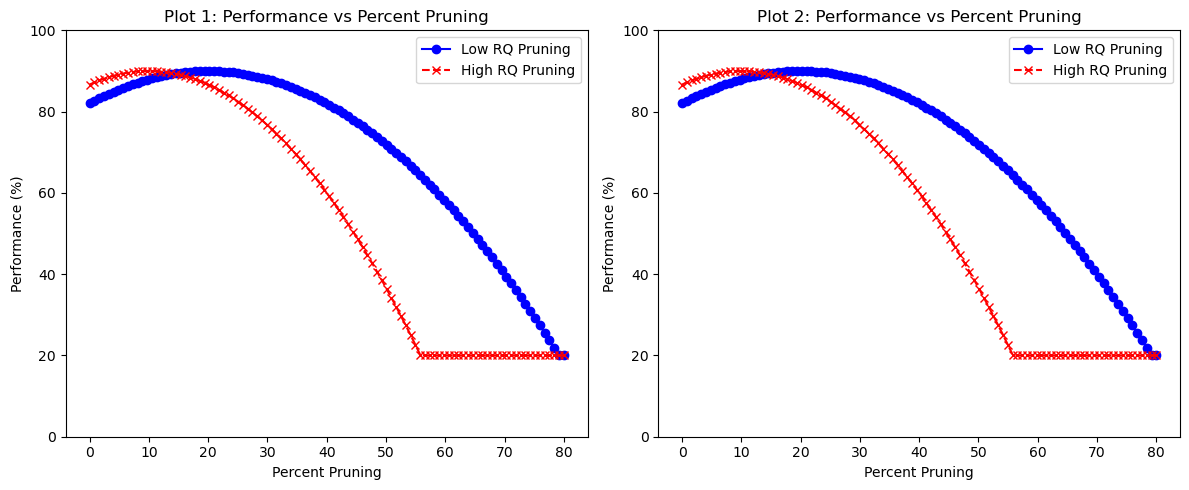

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic data for performance vs. percent pruning
percent_pruning = np.linspace(0, 80, 100)  # 0% to 80% pruning

# Generate synthetic performance data for low RQ pruning (starts at 90%, drops to 20%)
performance_low_rq = 90 - (percent_pruning - 20)**2 / 50
performance_low_rq[performance_low_rq < 20] = 20  # Set minimum performance to 20%

# Generate synthetic performance data for high RQ pruning (drops faster)
performance_high_rq = 90 - (percent_pruning - 10)**2 / 30
performance_high_rq[performance_high_rq < 20] = 20  # Set minimum performance to 20%

# Create two plots with similar data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
axes[0].plot(percent_pruning, performance_low_rq, label='Low RQ Pruning', color='blue', linestyle='-', marker='o')
axes[0].plot(percent_pruning, performance_high_rq, label='High RQ Pruning', color='red', linestyle='--', marker='x')
axes[0].set_title('Plot 1: Performance vs Percent Pruning')
axes[0].set_xlabel('Percent Pruning')
axes[0].set_ylabel('Performance (%)')
axes[0].legend()
axes[0].set_ylim([0, 100])

# Plot 2
axes[1].plot(percent_pruning, performance_low_rq, label='Low RQ Pruning', color='blue', linestyle='-', marker='o')
axes[1].plot(percent_pruning, performance_high_rq, label='High RQ Pruning', color='red', linestyle='--', marker='x')
axes[1].set_title('Plot 2: Performance vs Percent Pruning')
axes[1].set_xlabel('Percent Pruning')
axes[1].set_ylabel('Performance (%)')
axes[1].legend()
axes[1].set_ylim([0, 100])

# Show the plots
plt.tight_layout()
plt.show()